In [1]:
from matplotlib import use

use("Agg")

import matplotlib.pyplot as plt

In [2]:
import torch
from src.model import SequenceCNN

model = SequenceCNN()

model.load_state_dict(
    torch.load(
        "../models/liver_accessibility_cnn.pth"
    )
)

model.eval()

SequenceCNN(
  (conv1): Conv1d(4, 32, kernel_size=(5,), stride=(1,))
  (relu): ReLU()
  (pool): AdaptiveMaxPool1d(output_size=1)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [3]:
from src.datasets import SequenceDataset

dataset = SequenceDataset(
    "../data/processed/liver_accessibility.csv"
)

In [4]:
sample_x, sample_y, chrom = dataset[0]

print(sample_x.shape)
print(sample_y)
print(chrom)

torch.Size([4, 200])
tensor([0.])
chr1


In [5]:
sample_x = sample_x.unsqueeze(0)

print(sample_x.shape)

torch.Size([1, 4, 200])


In [6]:
conv_output = model.conv1(sample_x)

print(conv_output.shape)

torch.Size([1, 32, 196])


In [7]:
filter_0_activations = (
    conv_output[0, 0]
    .detach()
    .numpy()
)

print(filter_0_activations.shape)
print(filter_0_activations[:10])

(196,)
[-1.4629786  -1.3532004  -2.8849447  -1.4779568  -0.35114485 -0.5850743
 -0.6914311   0.612103   -1.7311118  -2.9994318 ]


In [8]:
import numpy as np
np.max(filter_0_activations)

0.7682953

In [9]:
max_position = filter_0_activations.argmax()

print(max_position)

115


In [10]:
import pandas as pd

dataset_df = pd.read_csv(
    "../data/processed/liver_accessibility.csv"
)

In [11]:
dataset_df.head()

,chrom,sequence,label
0,chr1,GCAAAGGCGACAGTCCCCACAGTGAAGGGCACTTGTCCATCTGGGG...,0
1,chr1,AAGGAAATATCTTCGTATAAATACTAGACAGAATGATTCTCAGAAA...,0
2,chr3,GTTTGGGGAGTAATTTTAATGCAGAAATACATCATTAATATACTGA...,0
3,chr1,TTACATTTTAGAAAAAACTCTTCTGGCTTACCTAACCTATGTTATG...,0
4,chr3,TTTCTGTTTTTTTATTGCTGTTAATGTTTAACATGAAAATAAGAAT...,1


In [12]:
sequence = dataset_df.iloc[0]["sequence"]

print(sequence)

GCAAAGGCGACAGTCCCCACAGTGAAGGGCACTTGTCCATCTGGGGACTGCTGGTGTTTAGAAGGGGATCTTGGGGCTGCGGCTTTTTCAGAAGGGGACTGGGGTAGAAGGACAACTTCCCCAATATTGTGGGAACACCTGAGTTCCTGCTGGCCGAAGTGAGTACCAAAAATTCTTTGGCAACCAGAAAAGTGACAGCT


In [13]:
motif_candidate = sequence[
    max_position:max_position + 5
]

print(motif_candidate)

CTTCC


#### Checking top-N 5bp motifs per filter

In [14]:
FILTER_INDEX = 0
top_motifs = []

for i in range(1000):

    sample_x, sample_y, chrom = dataset[i]

    sample_x = sample_x.unsqueeze(0)

    conv_output = model.conv1(sample_x)

    activations = (
        conv_output[
            0,
            FILTER_INDEX
        ]
        .detach()
        .numpy()
    )

    max_position = activations.argmax()

    max_activation = activations.max()

    sequence = dataset_df.iloc[i]["sequence"]

    motif_candidate = sequence[
        max_position:max_position + 5
    ]

    top_motifs.append({
        "motif": motif_candidate,
        "activation": max_activation
    })

In [15]:
top_motifs = sorted(
    top_motifs,
    key=lambda x: x["activation"],
    reverse=True
)

In [16]:
for entry in top_motifs[:20]:

    print(
        entry["motif"],
        entry["activation"]
    )

CGTCC 1.3891498
CGTCC 1.3891498
CGTCC 1.3891498
CGTCC 1.3891498
CGTCC 1.3891498
CGTCC 1.3891498
CGTCC 1.3891498
CGTCC 1.3891498
CGTCC 1.3891498
CGTCC 1.3891498
CGTCC 1.3891498
CGTCC 1.3891498
CGTCC 1.3891498
CGTCC 1.3891498
CGTCC 1.3891498
CGTCC 1.3891498
CGTCC 1.3891498
CGTCC 1.3891498
CGTCC 1.3891498
CGTCC 1.3891498


In [17]:
def gc_content(sequence):

    gc_count = (
        sequence.count("G")
        +
        sequence.count("C")
    )

    return gc_count / len(sequence)

In [18]:
for entry in top_motifs[:20]:

    motif = entry["motif"]

    print(
        motif,
        gc_content(motif)
    )

CGTCC 0.8
CGTCC 0.8
CGTCC 0.8
CGTCC 0.8
CGTCC 0.8
CGTCC 0.8
CGTCC 0.8
CGTCC 0.8
CGTCC 0.8
CGTCC 0.8
CGTCC 0.8
CGTCC 0.8
CGTCC 0.8
CGTCC 0.8
CGTCC 0.8
CGTCC 0.8
CGTCC 0.8
CGTCC 0.8
CGTCC 0.8
CGTCC 0.8


In [19]:
seen = set()

unique_top_motifs = []

for entry in top_motifs:

    motif = entry["motif"]

    if motif not in seen:

        unique_top_motifs.append(entry)

        seen.add(motif)

In [20]:
for entry in unique_top_motifs[:20]:

    print(
        entry["motif"],
        entry["activation"]
    )

CGTCC 1.3891498
CGGCC 1.3836505
CGTCA 1.3324614
CGGCA 1.3269621
CGTTC 1.1993032
CGGTC 1.1938039
CGTTA 1.1426147
CGGTA 1.1371155
CGTAC 1.0589612
CGGAC 1.0534619
CGTAA 1.0022727
CGGAA 0.9967736
CGCCC 0.95869625
CGCCA 0.9020078
CGCTC 0.7688496
CTTCC 0.7682953
CTGCC 0.7627961
GGTCC 0.7213336
GGGCC 0.71583444
CGCTA 0.71216124


In [21]:
from pyfaidx import Fasta
from pybigtools import open

genome = Fasta(
    "../data/reference/hg38.fa"
)

bb = open(
    "../data/raw/ENCFF106WBX.bigBed"
)

chrom_size = bb.chroms()["chr1"]

records = list(
    bb.records(
        "chr1",
        0,
        chrom_size
    )
)

rows = []

for record in records:

    start, end, name, score, strand, signalValue, pValue, qValue, peak = record

    rows.append({
        "chrom": "chr1",
        "start": start,
        "end": end,
        "signalValue": float(signalValue),
        "pValue": float(pValue),
        "qValue": float(qValue)
    })

df = pd.DataFrame(rows)

In [22]:
WINDOW_SIZE = 200

def extract_fixed_window(
    genome,
    chrom,
    start,
    peak_offset,
    window_size=WINDOW_SIZE
):

    summit = start + peak_offset

    half_window = window_size // 2

    window_start = summit - half_window
    window_end = summit + half_window

    sequence = genome[
        chrom
    ][
        window_start:window_end
    ].seq.upper()

    return sequence

In [23]:
positive_sequences = []

chromosomes = [
    "chr1",
    "chr2",
    "chr3"
]

for chrom in chromosomes:

    print(f"Processing {chrom}")

    chrom_size = bb.chroms()[chrom]

    records = list(
        bb.records(
            chrom,
            0,
            chrom_size
        )
    )

    for record in records:

        (
            start,
            end,
            name,
            score,
            strand,
            signalValue,
            pValue,
            qValue,
            peak
        ) = record

        sequence = extract_fixed_window(
            genome=genome,
            chrom=chrom,
            start=start,
            peak_offset=int(peak)
        )

        if len(sequence) != 200:
            continue

        positive_sequences.append({
            "chrom": chrom,
            "sequence": sequence,
            "label": 1
        })

Processing chr1
Processing chr2
Processing chr3


In [24]:
positive_gc = []

for entry in positive_sequences:

    gc = gc_content(
        entry["sequence"]
    )

    positive_gc.append(gc)

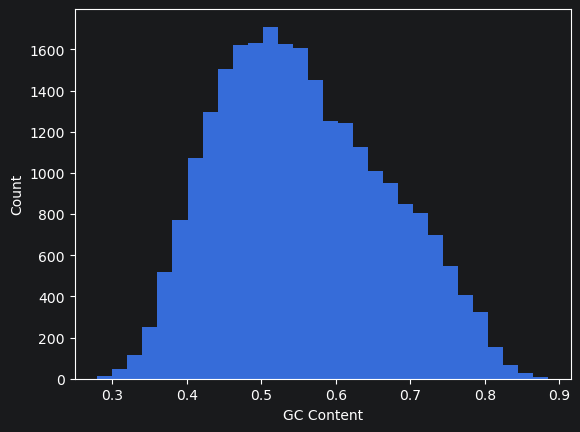

In [25]:
plt.hist(positive_gc, bins=30)

plt.xlabel("GC Content")
plt.ylabel("Count")

plt.show()

In [25]:
print(type(positive_gc))
print(len(positive_gc))
print(positive_gc[:10])

<class 'list'>
24708
[0.655, 0.725, 0.585, 0.725, 0.665, 0.67, 0.58, 0.61, 0.765, 0.785]


In [ ]:
small_gc = positive_gc[:1000]

plt.hist(small_gc, bins=30)

plt.show()

In [25]:
positive_gc = np.array(positive_gc)

print(positive_gc.dtype)

float64


In [25]:
plt.plot(positive_gc[:100])
plt.show()

C:\Users\dwhip\AppData\Local\Temp\ipykernel_34464\1021147304.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [26]:
peak_intervals = {}

for chrom in chromosomes:

    peak_intervals[chrom] = []

    chrom_size = bb.chroms()[chrom]

    records = list(
        bb.records(
            chrom,
            0,
            chrom_size
        )
    )

    for record in records:

        start = record[0]
        end = record[1]

        peak_intervals[chrom].append(
            (start, end)
        )

In [27]:
def overlaps_peak(
    chrom,
    query_start,
    query_end,
    peak_intervals
):

    for peak_start, peak_end in peak_intervals[chrom]:

        if (
            query_start < peak_end
            and
            query_end > peak_start
        ):
            return True

    return False

In [ ]:
import random
GC_TOLERANCE = 0.02

negative_sequences = []

for positive_entry in positive_sequences:

    target_gc = gc_content(
        positive_entry["sequence"]
    )

    while True:

        chrom = random.choice(
            chromosomes
        )

        chrom_size = bb.chroms()[chrom]

        random_start = random.randint(
            0,
            chrom_size - 200
        )

        random_end = random_start + 200

        if overlaps_peak(
            chrom,
            random_start,
            random_end,
            peak_intervals
        ):
            continue

        sequence = genome[
            chrom
        ][
            random_start:random_end
        ].seq.upper()

        if len(sequence) != 200:
            continue

        random_gc = gc_content(sequence)

        if abs(random_gc - target_gc) > GC_TOLERANCE:
            continue

        negative_sequences.append({
            "chrom": chrom,
            "sequence": sequence,
            "label": 0
        })

        break